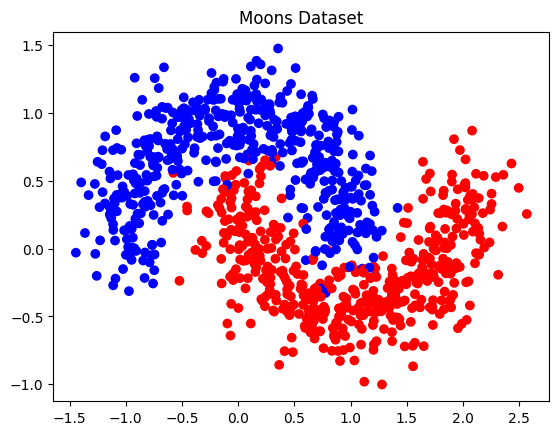

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn, optim

# Generate moons dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap='bwr')
plt.title("Moons Dataset")
plt.show()

# Optional: split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [3]:
class MoonNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()  # For binary classification
        )

    def forward(self, x):
        return self.net(x)

In [3]:
import torch
import torch.nn.functional as F
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# ===== 1. Dataset =====
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ===== 2. Hyperparameters =====
lr = 0.01
epochs = 20000
n_input = 2
n_hidden1 = 16
n_hidden2 = 16
n_output = 1

# ===== 3. Initialize weights and biases =====
torch.manual_seed(42)
W1 = torch.randn(n_input, n_hidden1) * 0.1
b1 = torch.zeros(1, n_hidden1)

W2 = torch.randn(n_hidden1, n_hidden2) * 0.1
b2 = torch.zeros(1, n_hidden2)

W3 = torch.randn(n_hidden2, n_output) * 0.1
b3 = torch.zeros(1, n_output)

# ===== 4. Training loop =====
for epoch in range(epochs):
    # --- Forward pass ---
    z1 = X_train @ W1 + b1           # (N, 16)
    a1 = torch.relu(z1)              # ReLU activation

    z2 = a1 @ W2 + b2                # (N, 16)
    a2 = torch.relu(z2)

    z3 = a2 @ W3 + b3                # (N, 1)
    a3 = torch.sigmoid(z3)           # Sigmoid output

    # --- Loss: Binary cross entropy ---
    loss = -(y_train * torch.log(a3 + 1e-8) + (1 - y_train) * torch.log(1 - a3 + 1e-8)).mean()

    # --- Backward pass (manual) ---
    # Output layer gradient
    dz3 = a3 - y_train                              # (N, 1)
    dW3 = a2.T @ dz3 / X_train.size(0)              # (16, 1)
    db3 = dz3.mean(dim=0, keepdim=True)             # (1, 1)

    # Hidden layer 2 gradient
    da2 = dz3 @ W3.T                                # (N, 16)
    dz2 = da2 * (z2 > 0).float()                    # ReLU derivative
    dW2 = a1.T @ dz2 / X_train.size(0)              # (16, 16)
    db2 = dz2.mean(dim=0, keepdim=True)             # (1, 16)

    # Hidden layer 1 gradient
    da1 = dz2 @ W2.T                                # (N, 16)
    dz1 = da1 * (z1 > 0).float()                    # ReLU derivative
    dW1 = X_train.T @ dz1 / X_train.size(0)         # (2, 16)
    db1 = dz1.mean(dim=0, keepdim=True)             # (1, 16)

    # --- Parameter update ---
    W3 -= lr * dW3
    b3 -= lr * db3
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# ===== 5. Evaluation =====
with torch.no_grad():
    z1 = X_test @ W1 + b1
    a1 = torch.relu(z1)
    z2 = a1 @ W2 + b2
    a2 = torch.relu(z2)
    z3 = a2 @ W3 + b3
    a3 = torch.sigmoid(z3)
    preds = (a3 >= 0.5).float()
    acc = (preds == y_test).float().mean()
    print(f"Test Accuracy: {acc:.4f}")

Epoch 0, Loss: 0.6953
Epoch 100, Loss: 0.6943
Epoch 200, Loss: 0.6936
Epoch 300, Loss: 0.6930
Epoch 400, Loss: 0.6926
Epoch 500, Loss: 0.6921
Epoch 600, Loss: 0.6914
Epoch 700, Loss: 0.6908
Epoch 800, Loss: 0.6901
Epoch 900, Loss: 0.6893
Epoch 1000, Loss: 0.6885
Epoch 1100, Loss: 0.6874
Epoch 1200, Loss: 0.6861
Epoch 1300, Loss: 0.6844
Epoch 1400, Loss: 0.6822
Epoch 1500, Loss: 0.6793
Epoch 1600, Loss: 0.6755
Epoch 1700, Loss: 0.6703
Epoch 1800, Loss: 0.6631
Epoch 1900, Loss: 0.6530
Epoch 2000, Loss: 0.6387
Epoch 2100, Loss: 0.6186
Epoch 2200, Loss: 0.5908
Epoch 2300, Loss: 0.5544
Epoch 2400, Loss: 0.5118
Epoch 2500, Loss: 0.4674
Epoch 2600, Loss: 0.4269
Epoch 2700, Loss: 0.3938
Epoch 2800, Loss: 0.3686
Epoch 2900, Loss: 0.3498
Epoch 3000, Loss: 0.3360
Epoch 3100, Loss: 0.3256
Epoch 3200, Loss: 0.3177
Epoch 3300, Loss: 0.3118
Epoch 3400, Loss: 0.3075
Epoch 3500, Loss: 0.3041
Epoch 3600, Loss: 0.3016
Epoch 3700, Loss: 0.2997
Epoch 3800, Loss: 0.2983
Epoch 3900, Loss: 0.2972
Epoch 4000, 